In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
dataset = pd.read_csv("1_boston_housing.csv")

In [3]:
print(dataset.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [4]:
X = dataset.drop("MEDV", axis=1)

# Target variable
y = dataset["MEDV"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()

In [ ]:
model.add(Dense(64, activation='relu', input_shape=(13,)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(Dense(32, activation='relu'))


In [ ]:
model.add(Dense(1))

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 594.3666 - mae: 22.4638 - val_loss: 514.9176 - val_mae: 21.1412
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 536.3359 - mae: 21.2198 - val_loss: 446.6936 - val_mae: 19.5489
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 439.4500 - mae: 18.9053 - val_loss: 335.2998 - val_mae: 16.5926
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 300.0381 - mae: 14.9797 - val_loss: 203.2546 - val_mae: 12.1708
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 168.7775 - mae: 10.3153 - val_loss: 100.7942 - val_mae: 7.6499
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 98.8168 - mae: 7.6818 - val_loss: 59.0543 - val_mae: 5.5553
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 64.2501 - mae: 6.2629 - val_loss: 41.5985 - val_mae: 4.6719
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 46.2224 - mae: 5.2889 - val_loss: 32.7736 - val_mae: 4.0593
Epoch 9/100
21/21 ━━━━

In [ ]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 11.8728 - mae: 2.4062
Test Loss (MSE): 11.872763633728027
Test MAE: 2.406231164932251


In [ ]:
predictions = model.predict(X_test)

print("\nPredicted Prices:")
print(predictions[:5])

print("\nActual Prices:")
print(y_test[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Predicted Prices:
[[28.132748]
 [34.948124]
 [17.49079 ]
 [26.525766]
 [15.932106]]

Actual Prices:
[23.6 32.4 13.6 22.8 16.1]


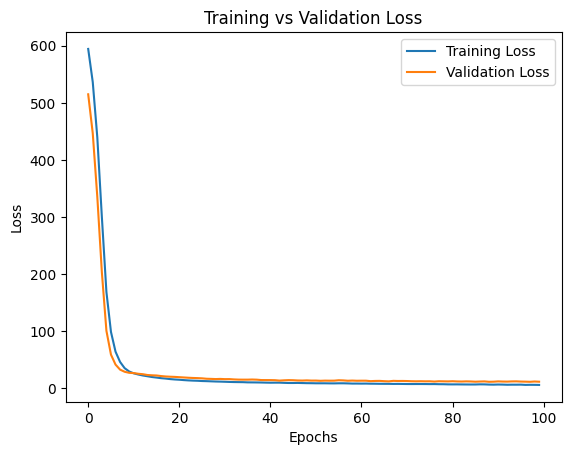

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()